<a href="https://colab.research.google.com/github/aragaoian/dip-notebooks/blob/master/notebooks/seam_carving.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Seam Carving

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
from tqdm import tqdm
import time
from numba import cuda

## 1. Load image

(np.float64(-0.5), np.float64(1427.5), np.float64(967.5), np.float64(-0.5))

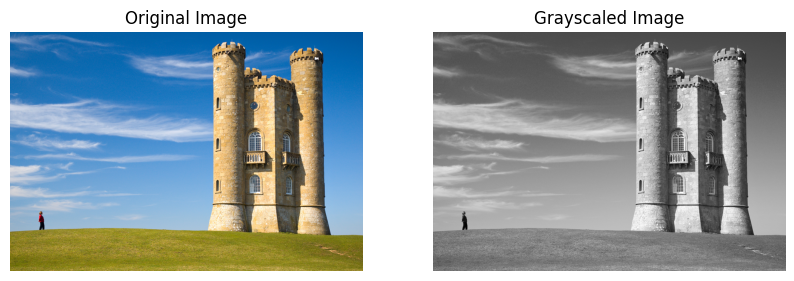

In [ ]:
img = cv2.imread("Broadway_tower_edit.jpg")

rgb_image = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
grayscale_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
axs[0].imshow(rgb_image, vmin=0, vmax=255)
axs[0].set_title("Original Image")
axs[0].axis("off")

axs[1].imshow(grayscale_img, cmap="gray", vmin=0, vmax=255)
axs[1].set_title("Grayscaled Image")
axs[1].axis("off")

## 2. Calculate Pixel Intensity

### Convolution

In [ ]:
def add_padding(img, padding_height, padding_width):
    h, w = img.shape

    padded_img = np.zeros((h + padding_height * 2, w + padding_width * 2))
    padded_img[padding_height : h + padding_height, padding_width : w + padding_width] = img

    return padded_img

In [ ]:
def conv2d(img, kernel, padding=True, floatOut=False):
    k_height, k_width = kernel.shape
    img_height, img_width = img.shape

    pad_height = k_height // 2
    pad_width = k_width // 2

    # Create a padded version of the image to handle edges
    if padding:
        img = add_padding(img, pad_height, pad_width)

    output = np.zeros((img_height, img_width), dtype=float)

    # Perform convolution
    # Iterate only on original image
    for i in range(pad_height, img_height + pad_height):
        for j in range(pad_width, img_width + pad_width):
            accumulation = 0
            for u in range(k_height):
                for v in range(k_width):
                    # Accumulate pixel and neighboors, multiplying kernel entry
                    # with the corresponding pixel entry
                    accumulation += kernel[u, v] * img[i - pad_height + u, j - pad_width + v]
            output[i-pad_height,j-pad_width] = accumulation
    if(floatOut):
      return output
    else:
      return np.array(output, dtype=np.uint8)


In [ ]:
# parellel
def calc_energy_map(img):
    # Sobel kernels
    x_kernel = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]])
    y_kernel = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]])

    gx = conv2d(img, x_kernel, padding=True, floatOut=True)
    gy = conv2d(img, y_kernel, padding=True, floatOut=True)

    # Calculate gradient magnitude
    magnitude = np.sqrt(gx**2 + gy**2)
    return np.clip(magnitude, 0, 255).astype(np.uint8)

## 3. Seam Algorithm

In [ ]:
def calc_minimal_energy(img, row, col):
    starting_col = max(0, col-1)
    row_slice = img[row-1, starting_col:col+2]
    col_index = starting_col + np.argmin(row_slice)
    return (
        min(row_slice),
        col_index
    )

def cumulative_sum(img):
    m,n = img.shape
    cumulative_sum_matrix = np.zeros((m,n))
    cumulative_sum_matrix[0] = img[0]

    # calculate cumulative sum
    for row in range(1, m):
        for col in range(n):
            cumulative_sum_matrix[row,col] = img[row,col] + calc_minimal_energy(cumulative_sum_matrix,row,col)[0]
    return cumulative_sum_matrix

def back_tracking(cumulated_matrix, seams_map):
    # compute seams, working back up the minimals to recover the seam
    m,n = cumulated_matrix.shape

    row_vals = cumulated_matrix[m-1]                   # last row
    col = np.argmin(row_vals)

    seam = []
    seam.append(col) # add the min column value of the minimal value
    for row in range(m-1, 1, -1):
        value, col = calc_minimal_energy(cumulated_matrix, row, col)
        seam.append(col)
    seams_map.append(seam)

    return seam

def remove_seam(img, seam):
    h, w = img.shape
    for row in range(h-1):
        col = seam[row]
        if col != (w - 1): # verify if col isn't the last column
            img[row, col:-1] = img[row, col+1:]
    return img[:, :-1]

def calc_seams(img, x=400, y=1):
    img = img.copy()
    seams_map = []
    for i in tqdm(range(x)):
        energy_map = calc_energy_map(img)
        cumulated_matrix = cumulative_sum(energy_map)
        seams = back_tracking(cumulated_matrix, seams_map)
        img = remove_seam(img, seams)
    return img, seams_map


In [ ]:
res, seams_map = calc_seams(grayscale_img)

In [ ]:
rgb_image = cv2.cvtColor(grayscale_img, cv2.COLOR_GRAY2BGR)
h, w, _ = rgb_image.shape

for seam in seams_map:
    for row in range(h-1):
        col = seam[row]
        # Mark seam in red
        rgb_image[row, col] = [0, 0, 255]

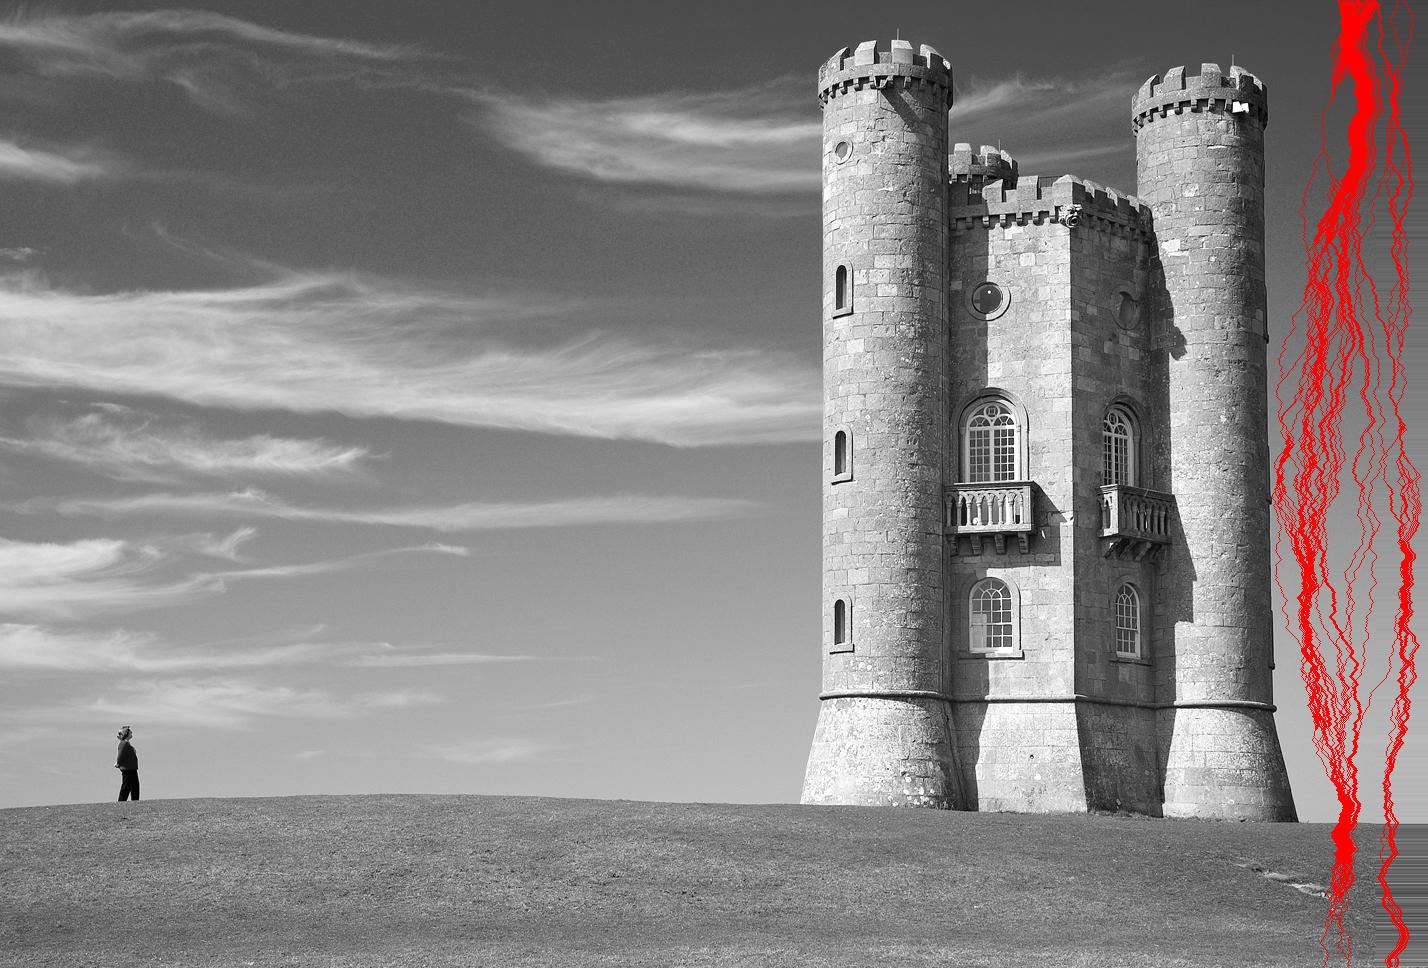

In [ ]:
cv2_imshow(rgb_image)